In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
print("All library Sucessful Import")

All library Sucessful Import


In [3]:
df =pd.read_csv("E-Commeres-Clean-Data set.csv")
df.head(5)

,order_id,order_date,month_name,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,...,tax_amount,shipping_cost,net_sales,product_cost,profit,profit or loss,profit_margin_percentage,customer_lifetime_value,is_repeat_customer,customer_order_count
0,ORD-301242,06-11-2023,November,16:37:47,Completed,Mobile App,CUST-003102,Jasmine Ryan,55,Male,...,61.07,12.03,945.40,588.33,345.04,Profit,36.50,12459.68,True,11
1,ORD-773460,24-12-2025,December,01:22:36,Completed,Website,CUST-003124,Scott Chase,26,Male,...,320.83,9.00,2018.41,2031.88,-22.47,Loss,-1.11,13032.48,True,11
2,ORD-449374,05-07-2021,July,14:24:21,Completed,Mobile App,CUST-012496,Marc Wheeler,69,Female,...,29.79,13.05,468.35,257.73,197.57,Profit,42.18,6159.44,True,6
3,ORD-567636,21-01-2023,January,07:20:26,Completed,Social Media,CUST-023928,Jennifer Smith,65,Male,...,34.39,20.85,546.52,277.84,247.83,Profit,45.35,5638.30,True,7
4,ORD-820028,13-05-2022,May,09:46:21,Completed,Social Media,CUST-012730,Jessica Wang,34,Female,...,421.35,23.03,2785.27,1231.88,1530.36,Profit,54.94,13240.10,True,8


In [5]:
df['order_date'] = pd.to_datetime(
    df['order_date'],
    format='%d-%m-%Y'
)

In [7]:
df['Month'] = df['order_date'].dt.month_name()

In [10]:
# add new month column in my data set 
df['order_date'] = pd.to_datetime(
    df['order_date'],
    format='%d-%m-%Y',
    errors='coerce'
)

df['Month'] = df['order_date'].dt.month_name()

In [11]:
df[['order_date', 'Month']].head()

,order_date,Month
0,2023-11-06,November
1,2025-12-24,December
2,2021-07-05,July
3,2023-01-21,January
4,2022-05-13,May


In [17]:
df.columns

Index(['order_id', 'order_date', 'order_time', 'order_status', 'sales_channel',
       'customer_id', 'customer_name', 'customer_age', 'gender',
       'customer_segment', 'customer_type', 'customer_city', 'customer_state',
       'customer_country', 'region', 'customer_postal_code', 'payment_method',
       'payment_status', 'currency', 'shipping_method', 'warehouse',
       'delivery_days', 'estimated_delivery_days', 'delivery_status',
       'return_status', 'return_reason', 'customer_rating', 'review_sentiment',
       'marketing_channel', 'campaign_name', 'coupon_code',
       'loyalty_points_earned', 'loyalty_points_redeemed', 'quantity',
       'gross_sales', 'discount_amount', 'tax_amount', 'shipping_cost',
       'net_sales', 'product_cost', 'profit', 'profit or loss',
       'profit_margin_percentage', 'customer_lifetime_value',
       'is_repeat_customer', 'customer_order_count', 'Month'],
      dtype='str')

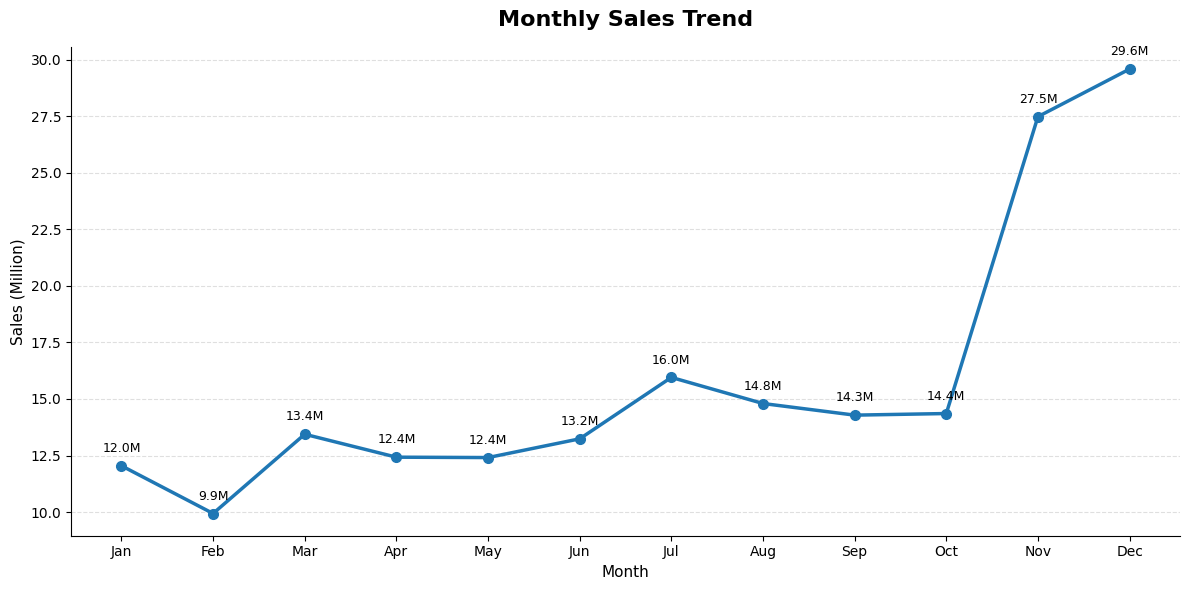

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Step 1: Convert order_date to datetime
df['order_date'] = pd.to_datetime(
    df['order_date'],
    format='%d-%m-%Y',
    errors='coerce'
)

# Step 2: Create Month Number and Month Name
df['Month_Number'] = df['order_date'].dt.month
df['Month'] = df['order_date'].dt.strftime('%b')

# Step 3: Group by month
Month = (
    df.groupby(['Month_Number', 'Month'])['gross_sales']
      .sum()
      .reset_index()
      .sort_values('Month_Number')
)

# Step 4: Convert sales to Millions
Month['Sales_Million'] = Month['gross_sales'] / 1_000_000

# Step 5: Plot
plt.figure(figsize=(12, 6))

plt.plot(
    Month['Month'],
    Month['Sales_Million'],
    marker='o',
    linewidth=2.5,
    markersize=7
)

# Add value labels
for x, y in zip(Month['Month'], Month['Sales_Million']):
    plt.annotate(
        f'{y:.1f}M',
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=9
    )

# Title and labels
plt.title(
    'Monthly Sales Trend',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Month', fontsize=11)
plt.ylabel('Sales (Million)', fontsize=11)

# Grid
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

# Remove unnecessary borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Make sure Jan-Dec is shown
plt.xticks(
    range(12),
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
)

plt.tight_layout()
plt.show()

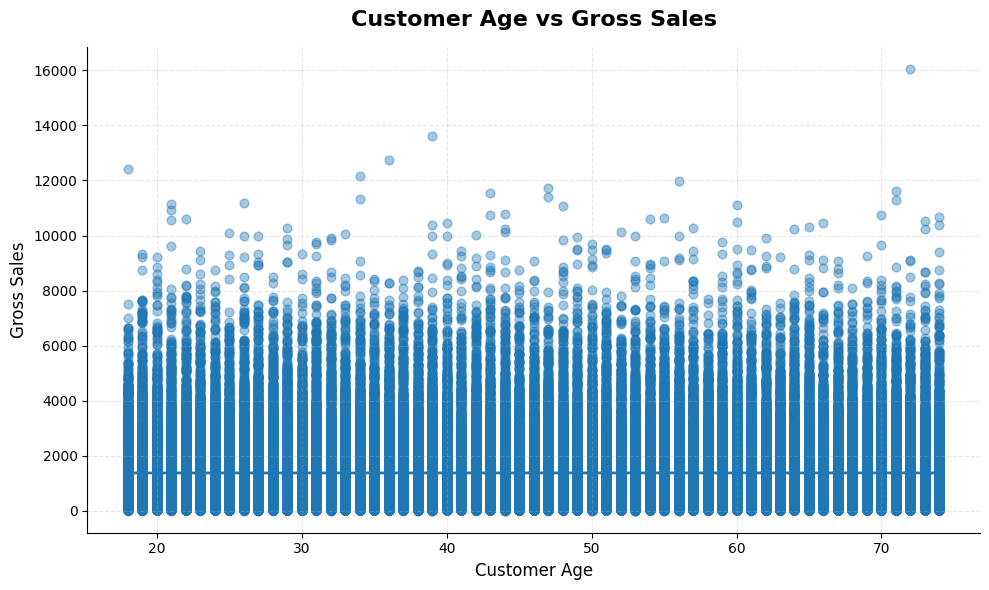

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='customer_age',
    y='gross_sales',
    scatter_kws={'alpha': 0.4, 's': 40},
    line_kws={'linewidth': 2}
)

plt.title(
    'Customer Age vs Gross Sales',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Customer Age', fontsize=12)
plt.ylabel('Gross Sales', fontsize=12)

plt.grid(
    linestyle='--',
    alpha=0.3
)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

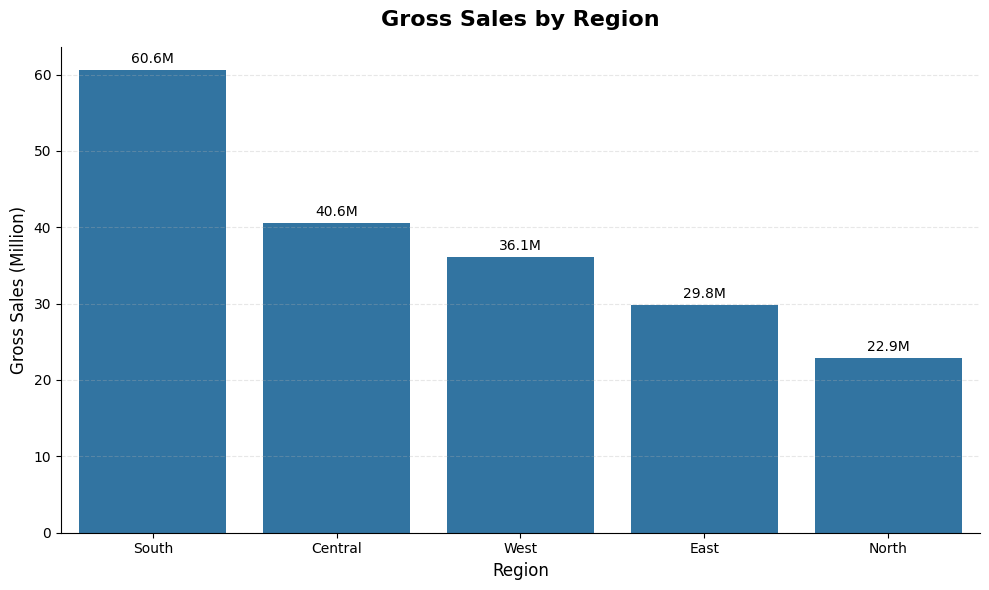

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Region-wise sales
region_sales = (
    df.groupby('region')['gross_sales']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

# Convert sales to millions
region_sales['Sales_Million'] = region_sales['gross_sales'] / 1_000_000

# Plot
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=region_sales,
    x='region',
    y='Sales_Million'
)

plt.title(
    'Gross Sales by Region',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Region', fontsize=12)
plt.ylabel('Gross Sales (Million)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add values on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1fM',
        padding=3,
        fontsize=10
    )

# Clean look
sns.despine()

plt.tight_layout()
plt.show()

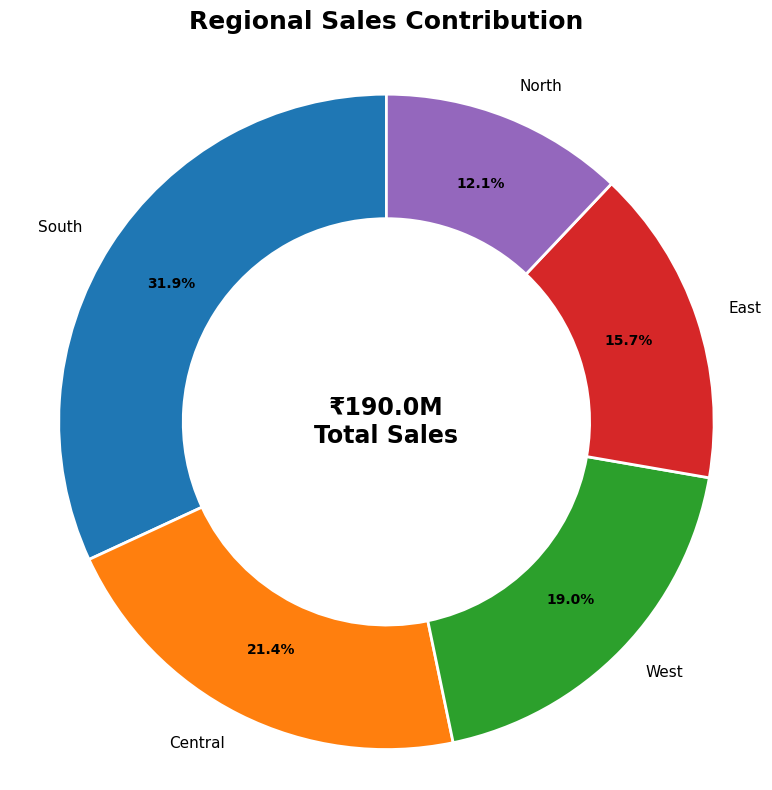

In [9]:
import matplotlib.pyplot as plt

region_sales = (
    df.groupby('region')['gross_sales']
      .sum()
      .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    region_sales,
    labels=region_sales.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.78,
    wedgeprops={
        'width': 0.38,
        'edgecolor': 'white',
        'linewidth': 2
    },
    textprops={
        'fontsize': 11
    }
)

# Make percentages bold
for text in autotexts:
    text.set_fontweight('bold')
    text.set_fontsize(10)

# Center KPI
total = region_sales.sum()

ax.text(
    0, 0,
    f'₹{total/1e6:.1f}M\nTotal Sales',
    ha='center',
    va='center',
    fontsize=17,
    fontweight='bold'
)

ax.set_title(
    'Regional Sales Contribution',
    fontsize=18,
    fontweight='bold',
    pad=25
)

ax.axis('equal')

plt.tight_layout()
plt.show()